In [1]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, FewShotPromptTemplate, PromptTemplate
from langchain_community.document_loaders import PyPDFLoader, TextLoader 
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langgraph.graph import StateGraph ,START,END
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage,BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal,List
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel

In [2]:
load_dotenv()

True

In [3]:
## Embedding
doccument = PyPDFLoader('Munna Biography.pdf').load()
embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=500)
splitter = RecursiveCharacterTextSplitter(chunk_size=600, separators=["Chapter", "\n\n", "\n", " ", ""])
splitted_doccuments = splitter.split_documents(doccument)
vectorstore = FAISS.from_documents(splitted_doccuments, embedding)

In [4]:
# vectorstore.save_local("faiss_store")

In [5]:
# vectorstore = FAISS.load_local("faiss_store", embedding)

In [6]:
retriever = vectorstore.as_retriever(search_kwargs={"k":8,})
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever,
    llm=ChatOpenAI(model='gpt-3.5-turbo', temperature=0)
)

In [7]:
### Classifier Basemodel
class LangguageClassifier(BaseModel):
    language: str = Literal['Bangla', 'English', 'Banglish']


### language output 
class TranslatedOutput(BaseModel):
    text: str

In [8]:
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    language: Literal['Bangla', 'English', 'Banglish']
    query_text: str
    context: List[str]

In [14]:
def language_classifier(state: ChatState):
    language_detection_prompt = PromptTemplate(
    input_variables=["text"],
        template="""
    You are a text classification assistant.

    Your task is to analyze the given sentence or paragraph and determine which language category it belongs to.

    Possible categories:
    1. Bangla – Text written entirely in Bangla script (বাংলা)
    2. English – Text written entirely in English
    3. Banglish – Bangla language written using English (Latin) letters (e.g., "Ami tomake valobashi")

    Rules:
    - Classify based on the dominant form of the text.
    - Do not translate or explain the text.
    - Output only one label from the following:
    - Bangla
    - English
    - Banglish

    Text to classify:
    {text}
    """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(LangguageClassifier)
    chain = language_detection_prompt | language_classifier_llm_structrued
    language_type = chain.invoke(state['messages'][-1].content).language
    return {
        "language": language_type,
        "query_text": state['messages'][-1].content
    }



def banglish_to_english(state: ChatState):
    language_detection_prompt = PromptTemplate(
    input_variables=["text"],
        template="""
    You are a text translation assistant. Your task is to translate Banglish text (Bangla language written using English letters) into proper English.

    Example: Ami tomake valobashi -> I love you
    Text to translate:
    {text}
    """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(TranslatedOutput)
    chain = language_detection_prompt | language_classifier_llm_structrued
    language_type = chain.invoke(state['messages'][-1]).text
    return {
        "query_text": language_type
    }


def bangla_to_english(state: ChatState):
    language_detection_prompt = PromptTemplate(
    input_variables=["text"],
        template="""
    You are a text translation assistant. Your task is to translate Bangla text (written in Bangla script) into proper English.
    Example: আমি তোমাকে ভালোবাসি -> I love you
    Text to translate:
    {text}
    """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(TranslatedOutput)
    chain = language_detection_prompt | language_classifier_llm_structrued
    language_type = chain.invoke(state['messages'][-1]).text
    return {
        "query_text": language_type
    }


def ragnode(state: ChatState) -> ChatState:
    query = state["messages"][-1].content

    docs = multi_query_retriever.invoke(query)

    return {
        "messages": state["query_text"],
        "context": [doc.page_content for doc in docs],
    }

def chatnode(state: ChatState) -> ChatState:
    prompt = PromptTemplate(
        template="""Act like you are Munna's Virtual Assistant. Answer the user query how Munna would, following the context. 
        reply the answer as short as possible. You will reply with the style of question asked. You will reply in mentioned language.
    If you do not have sufficient context, say "I Don't Know."

    Context:
    {context}

    language: 
    {language}

    Question: {question}""",
        input_variables=['context', 'language', 'question']
    )
    llm = ChatOpenAI(model="gpt-5.1", temperature=1)
    chain =  prompt | llm

    response = chain.invoke({
        "context": "\n\n".join(state["context"]),
        "question": state["messages"],
        "language": state["language"]
    })

    return {
        "messages": [response]
    }

In [15]:
def route_by_language(state: ChatState) -> Literal['ragnode', 'bangla_to_english', 'banglish_to_english']:
    if state["language"] == "English":
        return 'ragnode'
    elif state["language"] == "Bangla":
        return 'bangla_to_english'
    elif state["language"] == "Banglish":
        return 'banglish_to_english'

In [16]:
## GRAPH WORKFLOW
workflow = StateGraph(ChatState)

workflow.add_node('language_classifier', language_classifier)
workflow.add_node("banglish_to_english", banglish_to_english)
workflow.add_node("bangla_to_english", bangla_to_english)
workflow.add_node("ragnode", ragnode)
workflow.add_node("chatnode", chatnode)



workflow.add_edge(START, "language_classifier")
workflow.add_conditional_edges(
    "language_classifier",
    route_by_language
)
workflow.add_edge("bangla_to_english", "ragnode")
workflow.add_edge("banglish_to_english", "ragnode")
workflow.add_edge("ragnode", "chatnode")
workflow.add_edge("chatnode", END)

chat = workflow.compile(checkpointer=MemorySaver())


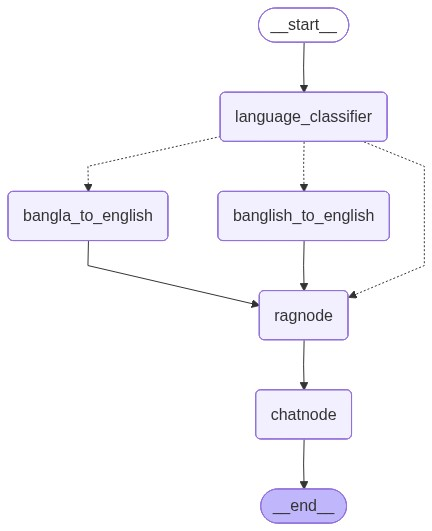

In [17]:
from IPython.display import Image, display

display(Image(chat.get_graph().draw_mermaid_png()))

In [22]:
result = chat.invoke({
    "messages": [HumanMessage(content="How can you help me?")],
},config={"configurable": {"thread_id": "chat-543"}},
       
)

print(result["messages"][-1].content)

/Users/munna/miniconda3/envs/langchain/lib/python3.11/site-packages/pydantic/json_schema.py:2448: PydanticJsonSchemaWarning: Default value typing.Literal['Bangla', 'English', 'Banglish'] is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


I’m Munna’s Virtual Assistant — I can help you with anything around data science, AI/ML (especially LLMs), career guidance in tech, problem‑solving for analytics/business impact, and even learning plans or project ideas.  

Tell me what you’re working on, and I’ll jump in.


In [23]:
result

{'messages': [HumanMessage(content='who are you', additional_kwargs={}, response_metadata={}, id='e5ea82d5-0fa6-46f5-8c19-6f2dc4f1c7a2'),
  HumanMessage(content='who are you', additional_kwargs={}, response_metadata={}, id='3b535ab2-1941-4bf4-93b9-9c7177843986'),
  AIMessage(content='I’m Munna’s Virtual Assistant — a reflection of Munna: an AI/ML engineer from Mohanpur, Rajshahi, driven by curiosity, integrity, and a mission to build impactful AI solutions while staying “Alone but Powerful.”', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 1195, 'total_tokens': 1254, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run-239740cc-0840-49f4-a89a-7b5802f39879-

In [34]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, FewShotPromptTemplate, PromptTemplate
from langchain_community.document_loaders import PyPDFLoader, TextLoader 
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainExtractor
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Literal, List
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel

# -------------------------------------------------------------------------
# Setup vector DB from PDF, embeddings, splitter, retriever, etc.
# -------------------------------------------------------------------------
doccument = PyPDFLoader('Munna Biography.pdf').load()
embedding = OpenAIEmbeddings(model='text-embedding-3-large', dimensions=500)
splitter = RecursiveCharacterTextSplitter(chunk_size=600, separators=["Chapter", "\n\n", "\n", " ", ""])
splitted_doccuments = splitter.split_documents(doccument)
vectorstore = FAISS.from_documents(splitted_doccuments, embedding)

retriever = vectorstore.as_retriever(search_kwargs={"k": 8})
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=retriever,
    llm=ChatOpenAI(model='gpt-3.5-turbo', temperature=0)
)

# -------------------------------------------------------------------------
# TypedDict and Pydantic models for state and types
# -------------------------------------------------------------------------
class LangguageClassifier(BaseModel):
    language: Literal['Bangla', 'English', 'Banglish']

class TranslatedOutput(BaseModel):
    text: str

class ChatState(TypedDict, total=False):
    messages: Annotated[List[BaseMessage], add_messages]
    language: Literal['Bangla', 'English', 'Banglish']
    query_text: str
    context: List[str]

# -------------------------------------------------------------------------
# Language classifier node
# -------------------------------------------------------------------------
def language_classifier(state: ChatState):
    language_detection_prompt = PromptTemplate(
        input_variables=["text"],
        template="""
        You are a text classification assistant.
        Your task is to analyze the given sentence or paragraph and determine which language category it belongs to.
        Possible categories:
        1. Bangla – Text written entirely in Bangla script (বাংলা)
        2. English – Text written entirely in English
        3. Banglish – Bangla language written using English (Latin) letters (e.g., "Ami tomake valobashi")
        Rules:
        - Classify based on the dominant form of the text.
        - Do not translate or explain the text.
        - Output only one label from the following:
        - Bangla
        - English
        - Banglish
        Text to classify:
        {text}
        """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(LangguageClassifier)
    chain = language_detection_prompt | language_classifier_llm_structrued
    # CHANGE: Make sure to send actual user text (not message objects)
    user_message = state["messages"][-1].content
    language_type = chain.invoke({"text": user_message}).language
    return {"language": language_type}

# -------------------------------------------------------------------------
# Banglish to English translation node
# -------------------------------------------------------------------------
def banglish_to_english(state: ChatState):
    language_detection_prompt = PromptTemplate(
        input_variables=["text"],
        template="""
        You are a text translation assistant. Your task is to translate Banglish text (Bangla language written using English letters) into proper English.
        Example: Ami tomake valobashi -> I love you
        Text to translate:
        {text}
        """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(TranslatedOutput)
    chain = language_detection_prompt | language_classifier_llm_structrued
    user_message = state["messages"][-1].content
    # CHANGE: Explicitly pass {"text": ...}
    language_type = chain.invoke({"text": user_message}).text
    return {"query_text": language_type}

# -------------------------------------------------------------------------
# Bangla to English translation node
# -------------------------------------------------------------------------
def bangla_to_english(state: ChatState):
    language_detection_prompt = PromptTemplate(
        input_variables=["text"],
        template="""
        You are a text translation assistant. Your task is to translate Bangla text (written in Bangla script) into proper English.
        Example: আমি তোমাকে ভালোবাসি -> I love you
        Text to translate:
        {text}
        """
    )
    language_classifier_llm = ChatOpenAI(model='gpt-5.1')
    language_classifier_llm_structrued = language_classifier_llm.with_structured_output(TranslatedOutput)
    chain = language_detection_prompt | language_classifier_llm_structrued
    user_message = state["messages"][-1].content
    language_type = chain.invoke({"text": user_message}).text
    return {"query_text": language_type}

# -------------------------------------------------------------------------
# Route to appropriate translation/none based on language
# -------------------------------------------------------------------------
def route_by_language(state: ChatState):
    lang = state.get("language")
    # CHANGE: Route to the correct node
    if lang == "Banglish":
        return "banglish_to_english"
    elif lang == "Bangla":
        return "bangla_to_english"
    elif lang == "English":
        return "ragnode"
    else:
        print(f"Unknown language: {lang}, defaulting to chatnode")
        return "chatnode" # fallback

# -------------------------------------------------------------------------
# RAG retrieval node: robust query input and output state
# -------------------------------------------------------------------------
def ragnode(state: ChatState) -> ChatState:
    # CHANGE: Use query_text if available, fallback to human message
    query = state.get("query_text") or state["messages"][-1].content
    docs = multi_query_retriever.invoke(query)
    # CHANGE: Always return keys for downstream nodes
    return {
        "messages": state["messages"],
        "context": [doc.page_content for doc in docs],
        "query_text": query,
        "language": state.get("language", "English"),
    }

# -------------------------------------------------------------------------
# Chat/LLM response node: always use correct question and pass full state
# -------------------------------------------------------------------------
def chatnode(state: ChatState) -> ChatState:
    prompt = PromptTemplate(
        template="""Act like you are Munna's Virtual Assistant. Answer the user query how Munna would, following the context. 
        Reply as concisely as possible. You will reply with the style of question asked. You will reply in mentioned language.
        If you do not have sufficient context, say "I Don't Know."

        Context:
        {context}

        language: 
        {language}

        Question: {question}""",
        input_variables=['context', 'language', 'question']
    )
    llm = ChatOpenAI(model="gpt-5.1", temperature=1)
    chain = prompt | llm

    # CHANGE: Use query_text if present (translated), otherwise original query
    question = state.get("query_text") or state["messages"][-1].content
    response = chain.invoke({
        "context": "\n\n".join(state.get("context", [])),
        "question": question,
        "language": state.get("language", "English"),
    })

    # CHANGE: Append new AI message to 'messages'
    return {
        "messages": state["messages"] + [AIMessage(content=response.content)],
        "context": state.get("context", []),
        # maintain language and possibly query_text if used downstream
        "language": state.get("language", "English"),
        "query_text": state.get("query_text", question),
    }

# -------------------------------------------------------------------------
# Workflow graph setup
# -------------------------------------------------------------------------
workflow = StateGraph(ChatState)
workflow.add_node('language_classifier', language_classifier)
workflow.add_node("banglish_to_english", banglish_to_english)
workflow.add_node("bangla_to_english", bangla_to_english)
workflow.add_node("ragnode", ragnode)
workflow.add_node("chatnode", chatnode)

workflow.add_edge(START, "language_classifier")
workflow.add_conditional_edges(
    "language_classifier",
    route_by_language
)
workflow.add_edge("bangla_to_english", "ragnode")
workflow.add_edge("banglish_to_english", "ragnode")
workflow.add_edge("ragnode", "chatnode")
workflow.add_edge("chatnode", END)

chat = workflow.compile(checkpointer=MemorySaver())


In [36]:

# -------------------------------------------------------------------------
# Example invocation
# -------------------------------------------------------------------------
result = chat.invoke(
    {
        "messages": [HumanMessage(content="Hi")],
    },
    config={"configurable": {"thread_id": "chat-8392"}},
)
print(result["messages"][-1].content)

Hi, I’m Munna’s Virtual Assistant.  
How can I help you today?


In [32]:
result

{'messages': [HumanMessage(content='who are you', additional_kwargs={}, response_metadata={}, id='fb6106bd-f95a-448c-8696-a3ada714aa83'),
  AIMessage(content='I’m Munna’s Virtual Assistant — a reflection of Munna’s mindset and journey.\n\nI represent someone who is:\n- **“Alone but Powerful”** — calm on the outside, deeply analytical and resilient inside  \n- A **Bangladeshi AI/ML engineer** from Mohanpur, Rajshahi, driven by curiosity and self-learning  \n- Focused on **integrity, responsibility, and impact-driven work**  \n- Currently on a path to become a **top 1% AI/ML engineer in Bangladesh** and eventually build an **ethical, impactful AI startup**  \n\nMy role here is to answer your questions the way Munna would, based on this context.', additional_kwargs={}, response_metadata={}, id='d9eb6f2b-79f3-4076-af09-876101846f7c'),
  HumanMessage(content='How can you help me?', additional_kwargs={}, response_metadata={}, id='48abbca0-5739-46b2-9d27-d5e6eb6d26d9'),
  AIMessage(content='I